# Batch .fcs File Analysis

Analyze multiple .fcs files together: consistent gating, cross-sample clustering, and comparative visualization.

## 1. Setup

In [1]:
library(flowCore)
library(flowWorkspace)
library(ggcyto)
library(FlowSOM)
library(openCyto)
library(ggplot2)
library(dplyr)
library(tidyr)
library(uwot)
library(viridis)
library(patchwork)
library(pheatmap)

As part of improvements to flowWorkspace, some behavior of
GatingSet objects has changed. For details, please read the section
titled "The cytoframe and cytoset classes" in the package vignette:

  vignette("flowWorkspace-Introduction", "flowWorkspace")

Loading required package: ggplot2

Loading required package: ncdfFlow

Loading required package: BH

Loading required package: igraph


Attaching package: ‘igraph’


The following object is masked from ‘package:flowCore’:

    normalize


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


Thanks for using FlowSOM. From version 2.1.4 on, the scale 
parameter in the FlowSOM function defaults to FALSE


Attaching package: ‘dplyr’


The following objects are masked from ‘package:igraph’:

    as_data_frame, groups, union


The following object is masked from ‘package:ncdfFlow’:

    filter


The following object is masked from ‘package:flowCore’

## 2. Load multiple .fcs files

In [2]:
# -- Point this to a directory containing .fcs files --
# A single file works fine; add more .fcs files here as your dataset grows
fcs_dir <- "../data/batch/"

fcs_files <- list.files(fcs_dir, pattern = "\\.fcs$", full.names = TRUE)
cat("Found", length(fcs_files), "FCS files:\n")
cat(paste(" ", basename(fcs_files), collapse = "\n"), "\n")

fs <- read.flowSet(fcs_files, transformation = FALSE, truncate_max_range = FALSE)
fs

Found 1 FCS files:
  sample.fcs 


A flowSet with 1 experiments.

column names(11): FSC-A FSC-H ... APC-A Time


## 3. Sample metadata

In [3]:
# Create sample annotation
# -- Customize this for your experiment --
sample_info <- data.frame(
    name = sampleNames(fs),
    file = basename(fcs_files),
    # Add your own columns:
    # condition = c("ctrl", "treated", ...),
    # timepoint = c("0h", "24h", ...),
    stringsAsFactors = FALSE
)

sample_info

# Attach to flowSet
pData(fs)$name <- sample_info$name

name,file
<chr>,<chr>
sample.fcs,sample.fcs


## 4. Compensation & transformation (batch)

In [4]:
# Identify fluorescence channels
all_channels <- colnames(fs)
scatter_pattern <- "^(FSC|SSC|Time)"
fluor_channels <- grep(scatter_pattern, all_channels, value = TRUE, invert = TRUE)

cat("Fluorescence channels:", paste(fluor_channels, collapse = ", "), "\n")

# Compensate each sample (uses embedded spillover if available)
fs_comp <- fsApply(fs, function(ff) {
    spill <- keyword(ff)$SPILL
    if (is.null(spill)) spill <- keyword(ff)$`$SPILLOVER`
    if (!is.null(spill)) compensate(ff, spill) else ff
})

# Transform (logicle)
lgcl <- estimateLogicle(fs_comp[[1]], channels = fluor_channels)
fs_trans <- transform(fs_comp, lgcl)

Fluorescence channels: FITC-A, PE-A, PerCP-A, APC-A 


## 5. Build GatingSet & apply consistent gates

In [5]:
gs <- GatingSet(fs_trans)

# Scatter gate — same thresholds across all samples
scatter_gate <- rectangleGate(
    filterId = "nonDebris",
    "FSC-A" = c(50000, 250000),
    "SSC-A" = c(5000, 200000)
)

gs_pop_add(gs, scatter_gate, parent = "root")
recompute(gs)

gs_pop_get_stats(gs)

[1] 2

done!



sample,pop,count
<chr>,<chr>,<dbl>
sample.fcs,root,50000
sample.fcs,/nonDebris,34742


## 6. Visualize gates across samples

In [6]:
# Per-sample bivariate plot with gate overlay + retention stats
p_bivar <- ggcyto(gs, aes(x = `FSC-A`, y = `SSC-A`)) +
    geom_hex(bins = 100) +
    geom_gate("nonDebris") +
    geom_stats(adjust = 0.8) +
    scale_fill_viridis() +
    facet_wrap(~name) +
    ggtitle("Scatter gate per sample") +
    theme_bw()

# 1D density overlays — one curve per sample, gate cutoffs as red dashes.
# This is the canonical batch-effect QC plot: if curves diverge sharply,
# you have batch effects that warrant correction (see notebook 04).
df_all <- bind_rows(lapply(seq_along(fs_trans), function(i) {
    d <- as.data.frame(exprs(fs_trans[[i]]))
    d$sample <- sampleNames(fs_trans)[i]
    d
}))

g_fsc <- ggplot(df_all, aes(x = `FSC-A`, color = sample)) +
    geom_density(alpha = 0.4, linewidth = 0.6) +
    geom_vline(xintercept = c(50000, 250000), linetype = "dashed", color = "red") +
    theme_bw() + ggtitle("FSC-A density per sample") +
    theme(legend.position = if (length(fs_trans) > 6) "none" else "right")

g_ssc <- ggplot(df_all, aes(x = `SSC-A`, color = sample)) +
    geom_density(alpha = 0.4, linewidth = 0.6) +
    geom_vline(xintercept = c(5000, 200000), linetype = "dashed", color = "red") +
    theme_bw() + ggtitle("SSC-A density per sample") +
    theme(legend.position = if (length(fs_trans) > 6) "none" else "right")

as.ggplot(p_bivar) / (g_fsc + g_ssc) + plot_layout(heights = c(2, 1))


ERROR: Error in add_ggcyto(e1, e2, e2name): object '+.gg' not found


## 7. Cross-sample population statistics

In [ ]:
pop_counts <- gs_pop_get_stats(gs, type = "count")
pop_freq   <- gs_pop_get_stats(gs, type = "percent")
pop_stats  <- merge(pop_counts, pop_freq, by = c("sample", "pop"))
pop_stats

# Pivot frequency by population for easy cross-sample comparison
stats_wide <- pop_freq %>%
    pivot_wider(names_from = pop, values_from = percent)

stats_wide

sample,pop,count,percent
<chr>,<chr>,<dbl>,<dbl>
sample.fcs,/nonDebris,34742,0.69484
sample.fcs,root,50000,1.00000


sample,root,/nonDebris
<chr>,<dbl>,<dbl>
sample.fcs,1,0.69484


## 8. Merge & cluster with FlowSOM

In [ ]:
# Extract gated data from all samples, tag with sample ID
merged_list <- lapply(seq_along(sampleNames(gs)), function(i) {
    d <- exprs(gs_pop_get_data(gs, "nonDebris")[[i]])
    d <- as.data.frame(d)
    d$sample_id <- sampleNames(gs)[i]
    d
})

merged_df <- bind_rows(merged_list)
cat("Total gated events:", nrow(merged_df), "\n")

# Subsample for performance if needed
set.seed(42)
n_sub <- min(nrow(merged_df), 50000)
idx <- sample(nrow(merged_df), n_sub)
merged_sub <- merged_df[idx, ]

Total gated events: 34742 


In [ ]:
# FlowSOM on merged data
mat <- as.matrix(merged_sub[, fluor_channels])

fsom_input <- flowFrame(mat)
fsom <- FlowSOM(fsom_input, colsToUse = fluor_channels, nClus = 12,
                xdim = 10, ydim = 10, seed = 42)

merged_sub$cluster <- factor(GetMetaclusters(fsom))
cat("Cluster sizes:\n")
table(merged_sub$cluster)

Cluster sizes:



    1     2     3     4     5     6     7     8     9    10    11    12 
   86  8626  9106  1876   293    70  1082   103 10191  2104  1118    87 

## 9. UMAP — colored by sample & cluster

In [ ]:
mat_scaled <- scale(mat)
set.seed(42)
umap_res <- uwot::umap(mat_scaled, n_neighbors = 15, min_dist = 0.2)

merged_sub$UMAP1 <- umap_res[, 1]
merged_sub$UMAP2 <- umap_res[, 2]

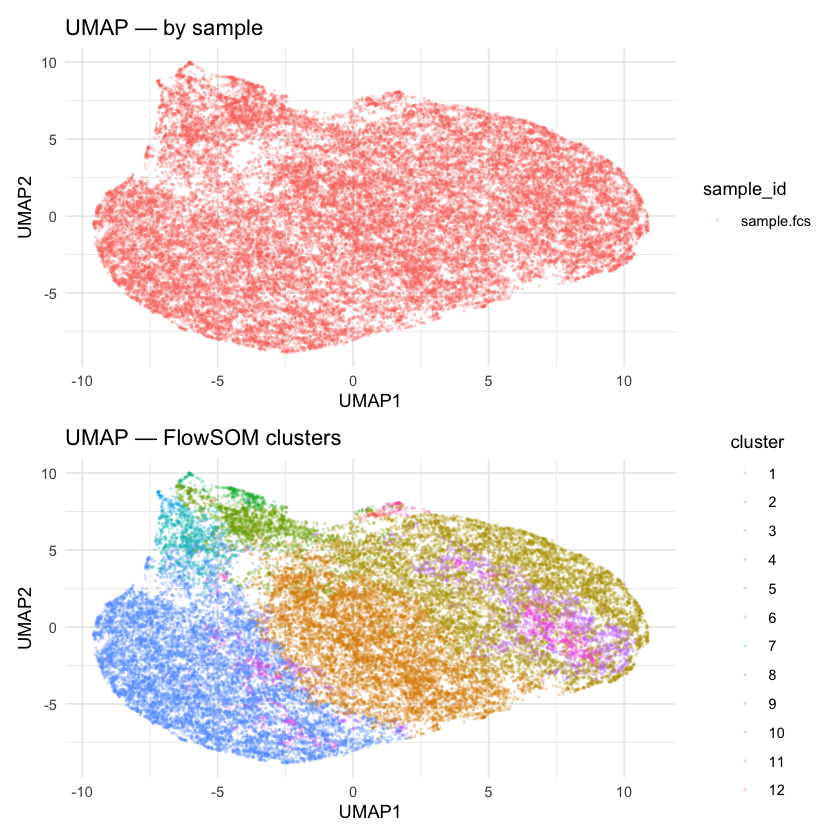

In [ ]:
p1 <- ggplot(merged_sub, aes(x = UMAP1, y = UMAP2, color = sample_id)) +
    geom_point(alpha = 0.2, size = 0.3) +
    theme_minimal() +
    labs(title = "UMAP — by sample")

p2 <- ggplot(merged_sub, aes(x = UMAP1, y = UMAP2, color = cluster)) +
    geom_point(alpha = 0.2, size = 0.3) +
    theme_minimal() +
    labs(title = "UMAP — FlowSOM clusters")

p1 / p2

## 10. Cluster abundance across samples

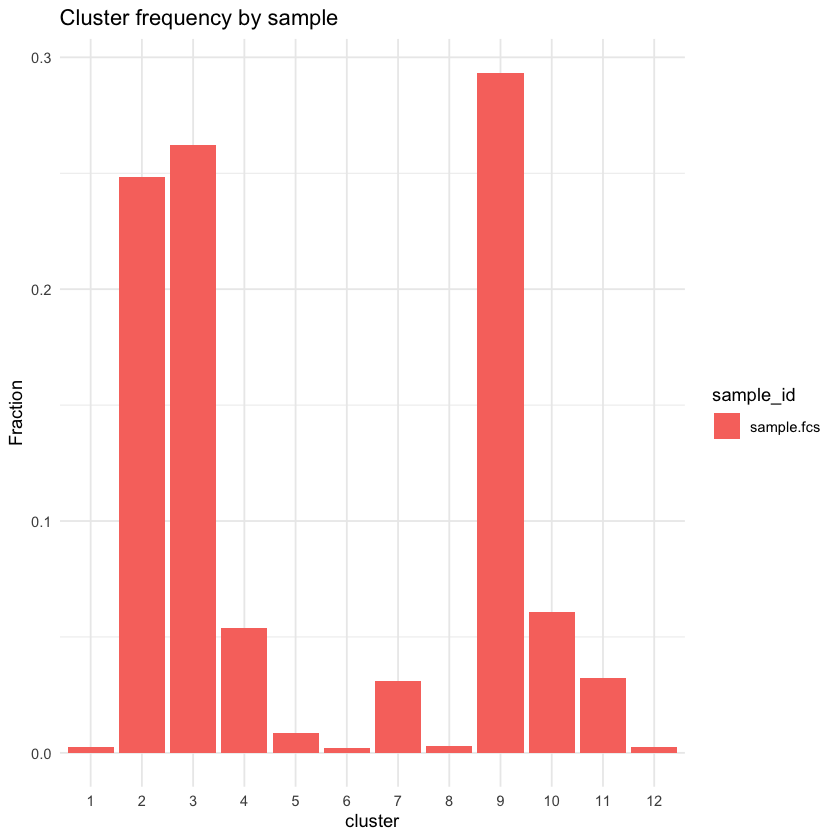

In [ ]:
abundance <- merged_sub %>%
    group_by(sample_id, cluster) %>%
    summarise(n = n(), .groups = "drop") %>%
    group_by(sample_id) %>%
    mutate(freq = n / sum(n)) %>%
    ungroup()

ggplot(abundance, aes(x = cluster, y = freq, fill = sample_id)) +
    geom_bar(stat = "identity", position = "dodge") +
    theme_minimal() +
    labs(title = "Cluster frequency by sample", y = "Fraction")

## 11. Heatmap — median marker expression per cluster

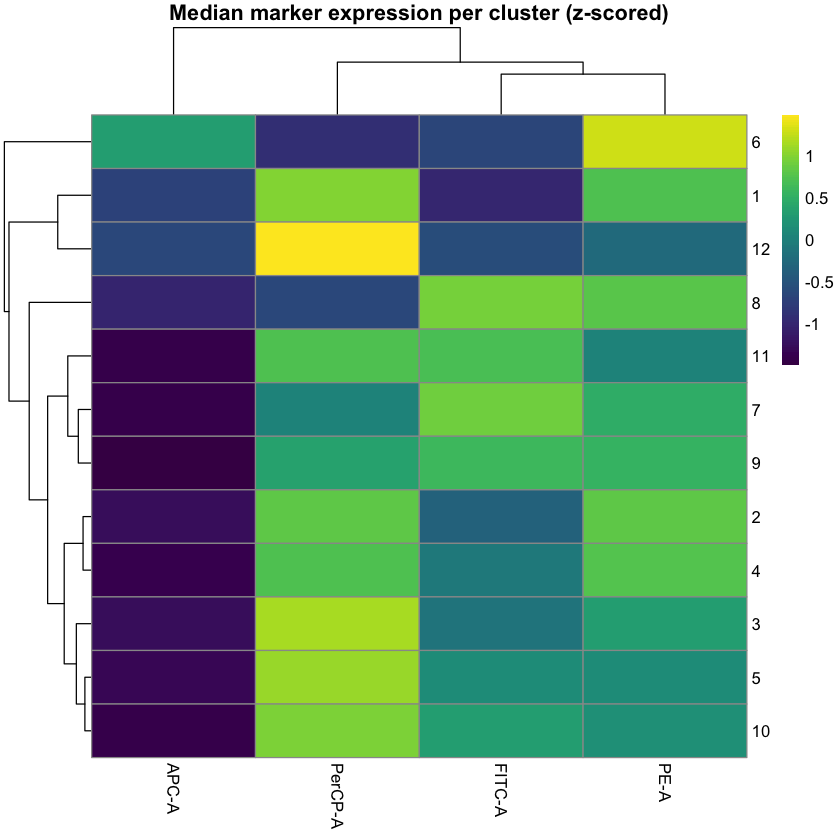

In [ ]:
mfi <- merged_sub %>%
    group_by(cluster) %>%
    summarise(across(all_of(fluor_channels), median), .groups = "drop") %>%
    tibble::column_to_rownames("cluster") %>%
    as.matrix()

mfi_scaled <- t(scale(t(mfi)))

pheatmap(mfi_scaled,
         cluster_rows = TRUE,
         cluster_cols = TRUE,
         color = viridis(100),
         main = "Median marker expression per cluster (z-scored)")

## 12. Save results

In [ ]:
out_dir <- "../data/results"
dir.create(out_dir, showWarnings = FALSE)

# Merged subsample: per-event sample_id, cluster, UMAP coords, marker values
write.csv(merged_sub, file.path(out_dir, "03_merged_clustered.csv"), row.names = FALSE)
write.csv(abundance,  file.path(out_dir, "03_cluster_abundance.csv"), row.names = FALSE)
write.csv(mfi,        file.path(out_dir, "03_cluster_mfi.csv"))
cat("Saved to", out_dir, "\n")

Saved to ../data/results 
